# AIML Week 1 - Beginner Task

## Titanic Dataset: Data Loading, Cleaning, Analysis and Visualization

This notebook demonstrates basic data analysis using the Titanic dataset.

### Objectives
- Load a public dataset using Pandas.
- Inspect missing values, duplicate rows, and data types.
- Clean the dataset with appropriate justification.
- Generate basic summary statistics.
- Create visualizations using Matplotlib and Seaborn.
- Document each step clearly using comments and Markdown.

In [6]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Load the Titanic dataset from the CSV file
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 891
Number of columns: 12


## 1. Initial Dataset Inspection

First, we inspect the first few rows of the dataset to understand its structure and the type of information it contains.

In [9]:
# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Information

The `info()` function provides information about the columns, number of non-null values, and data types.

In [10]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Display the number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [12]:
# Display all column names
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## 2. Checking Missing Values

We check each column for missing values before cleaning the dataset.

In [13]:
# Check the number of missing values in each column
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [33]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64


## 3. Checking Duplicate Rows

Duplicate rows can affect the accuracy of analysis, so we check for them before cleaning.

In [14]:
# Check for duplicate rows
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [15]:
# Check the data type of every column
print("Data types:")
print(df.dtypes)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## 4. Summary Statistics

We generate basic statistical information for the numerical columns before cleaning.

In [16]:
# Generate basic summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
# Display frequency counts for categorical columns
print("Sex value counts:")
print(df["Sex"].value_counts())

print("\nEmbarked value counts:")
print(df["Embarked"].value_counts())

print("\nSurvived value counts:")
print(df["Survived"].value_counts())

Sex value counts:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Survived value counts:
Survived
0    549
1    342
Name: count, dtype: int64


## 5. Data Cleaning

### Handling Missing Values

- `Age`: Missing ages will be replaced with the median because age is numerical and the median is less affected by extreme values.
- `Embarked`: Missing values will be replaced with the mode because this is a categorical column.
- `Cabin`: The Cabin column has a very large number of missing values, so it will be removed because filling most of the column would introduce unreliable information.

In [18]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most frequent category (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it contains too many missing values
df.drop(columns=["Cabin"], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


### Removing Duplicate Rows

Duplicate rows are removed to ensure that the same record is not counted more than once.

In [19]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Duplicate rows removed successfully!")

Duplicate rows removed successfully!


In [20]:
# Check data types after cleaning
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


### Data Type Check

The data types were inspected after cleaning. The numerical columns such as Age and Fare are stored as numerical values, while categorical columns such as Sex and Embarked are stored as object/string values. No unnecessary type conversion is required.

## 6. Verification After Cleaning

We now verify that the dataset no longer contains missing values.

In [21]:
# Verify missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [22]:
# Verify duplicate rows after cleaning
print("Number of duplicate rows after cleaning:")
print(df.duplicated().sum())

Number of duplicate rows after cleaning:
0


In [23]:
# Display final dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## 7. Summary Statistics After Cleaning

The cleaned dataset is summarized using descriptive statistics and frequency counts.

In [24]:
# Numerical summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
# Value counts for categorical variables
print("Gender distribution:")
print(df["Sex"].value_counts())

print("\nPassenger class distribution:")
print(df["Pclass"].value_counts())

print("\nSurvival distribution:")
print(df["Survived"].value_counts())

Gender distribution:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger class distribution:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Survival distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [26]:
# Calculate basic statistics for Age
print("Mean Age:", df["Age"].mean())
print("Median Age:", df["Age"].median())
print("Maximum Age:", df["Age"].max())

Mean Age: 29.36158249158249
Median Age: 28.0
Maximum Age: 80.0


## 8. Data Visualization

### Histogram of Passenger Ages

A histogram is used to understand the distribution of passenger ages.

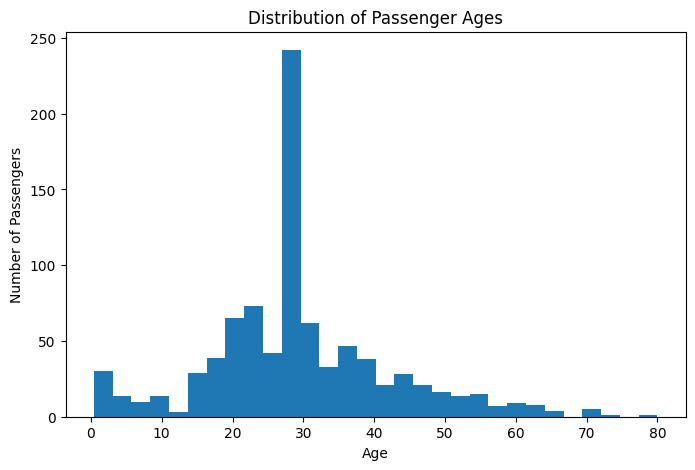

In [27]:
# Create a histogram showing the distribution of passenger ages
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=30)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Bar Chart of Survival

A bar chart is used to compare the number of passengers who survived and did not survive.

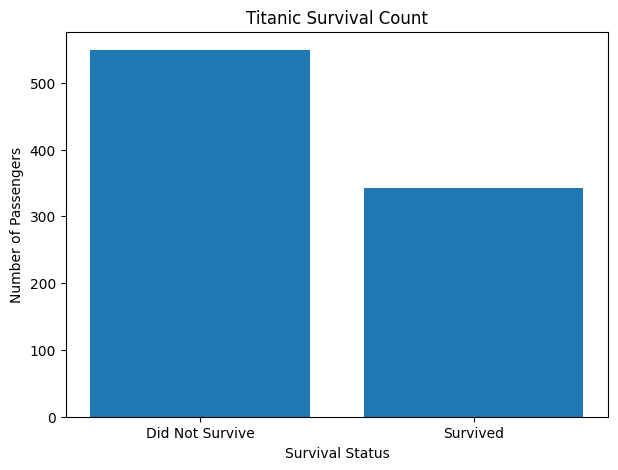

In [28]:
# Create a bar chart showing survival counts
survival_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(["Did Not Survive", "Survived"], survival_counts)

plt.title("Titanic Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

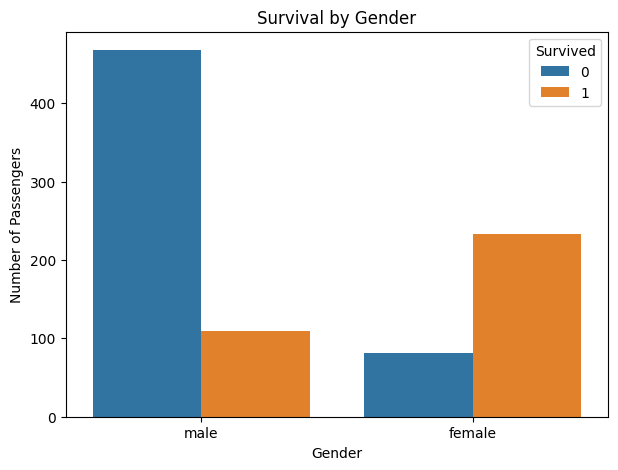

In [29]:
# Compare survival counts by gender
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

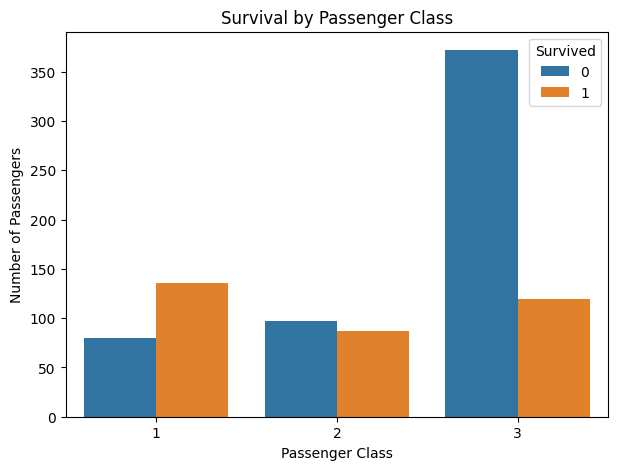

In [30]:
# Compare survival counts across passenger classes
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## 9. Observations and Conclusion

### Observations

1. The Titanic dataset contains 891 passenger records, which satisfies the requirement of having at least 200 rows.
2. Missing values were identified in the dataset and handled appropriately.
3. Missing Age values were replaced with the median because median is less affected by extreme values.
4. Missing Embarked values were replaced with the mode because Embarked is a categorical variable.
5. The Cabin column was removed because it contained a large proportion of missing values.
6. Duplicate rows were checked and removed.
7. The data types of the columns were inspected and were appropriate after cleaning.
8. Summary statistics were generated using descriptive statistics, mean, median, and value counts.
9. The histogram shows the distribution of passenger ages.
10. The survival bar chart shows the number of passengers who survived and did not survive.
11. The additional visualizations show differences in survival across gender and passenger class.

### Conclusion

The Titanic dataset was successfully loaded, inspected, cleaned, and analyzed using Pandas. Missing values and duplicate rows were handled appropriately, and the dataset was prepared for analysis. Basic statistical summaries and visualizations were created using Pandas, Matplotlib, and Seaborn.

In [31]:
# Save the cleaned dataset as a new CSV file
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [34]:
# Display the first 5 rows of the final cleaned dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
